<a href="https://colab.research.google.com/github/FarahBelghith2/PFE/blob/main/modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## CRISP-DM – Phase 4 : Modeling

Ce notebook couvre :
- la construction des bases modeling,
- l’entraînement d’un modèle multisource,
- l’évaluation interne,
- la courbe d’apprentissage,
- un test externe,
- une logique de promotions,
- la sauvegarde des artefacts du modèle.

In [ ]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from flask import Flask, request, jsonify
import pickle
import pandas as pd

sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/PFE")

from features_utils import (
    parse_heure_num,
    month_to_season_fr,
    partie_jour,
    extract_event_info,
    extract_event_info_multi,
    choisir_evenement_principal,
    format_event_display
)

print("✅ Import réussi")

✅ Import réussi


## Chargement des bases de données

Nous chargeons :
- la base A préparée,
- la base B brute utilisée comme seconde source.


In [ ]:
df_A_prepared = pd.read_csv("/content/drive/MyDrive/PFE/base_A_finale_2024_2025.csv")

print("Base A :", df_A_prepared.shape)


Base A : (17379, 20)


## Fonctions utilitaires et d’adaptation des bases

Les fonctions suivantes permettent :
- d’harmoniser les colonnes,
- d’extraire les événements,
- de rendre les bases compatibles avec le modèle.

**🛠️ 4.1 Fonctions de nettoyage et de Feature Engineering
Définition des fonctions permettant d'harmoniser n'importe quelle base de données (Paris, Washington, Séoul) vers un format unique compréhensible par notre algorithme. Extraction des caractéristiques temporelles (Feature Engineering).**

In [ ]:
def drop_duplicate_columns(df):
    df = df.copy()
    return df.loc[:, ~df.columns.duplicated()]


def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("\ufeff", "", regex=False)
        .str.replace(" ", "_", regex=False)
    )
    return df


def rename_with_aliases(df, aliases):
    df = df.copy()

    for canonical_name, possible_names in aliases.items():
        if canonical_name in df.columns:
            cols_to_drop = [
                col for col in possible_names
                if col in df.columns and col != canonical_name
            ]
            if cols_to_drop:
                df = df.drop(columns=cols_to_drop, errors="ignore")
        else:
            for alias in possible_names:
                if alias in df.columns:
                    df = df.rename(columns={alias: canonical_name})
                    break

    return drop_duplicate_columns(df)




In [ ]:
def adapt_any_base(df_raw, site_id="unknown_site"):
    df = df_raw.copy()

    df = normalize_columns(df)
    df = rename_with_aliases(df, COLUMN_ALIASES)

    required_cols = [
        "date", "heure_num", "ferie", "jour_ouvrable",
        "meteo", "temperature_c", "humidite_pct", "vent_kmh",
        "reservations", "nom_event_local", "is_vacances_scolaires"
    ]
    for col in required_cols:
        if col not in df.columns:
            if col in ["ferie", "jour_ouvrable", "is_vacances_scolaires"]:
                df[col] = 0
            elif col == "nom_event_local":
                df[col] = "Aucun"
            else:
                df[col] = np.nan

    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date"]).copy()

    df["heure_num"] = df["heure_num"].apply(parse_heure_num)
    df = df.dropna(subset=["heure_num"]).copy()
    df["heure_num"] = df["heure_num"].astype(int)

    df["annee"] = df["date"].dt.year
    df["mois"] = df["date"].dt.month
    df["jour_mois"] = df["date"].dt.day
    df["jour_semaine_num"] = df["date"].dt.weekday

    mapping_jours = {
        0: "lundi",
        1: "mardi",
        2: "mercredi",
        3: "jeudi",
        4: "vendredi",
        5: "samedi",
        6: "dimanche"
    }
    df["jour_semaine"] = df["jour_semaine_num"].map(mapping_jours)
    df["est_weekend"] = df["jour_semaine_num"].isin([5, 6]).astype(int)

    df["saison"] = df["mois"].apply(month_to_season_fr)
    df["saison"] = df["saison"].astype(str).str.strip().str.lower()

    df["meteo"] = df["meteo"].astype(str).str.strip().str.lower()
    mapping_meteo = {
        "ensoleille": "ensoleillé",
        "soleil": "ensoleillé",
        "clear": "ensoleillé",
        "clair": "ensoleillé",
        "rain": "pluvieux",
        "pluie": "pluvieux",
        "cloudy": "nuageux",
        "nuage": "nuageux",
        "storm": "orageux",
        "orage": "orageux",
        "1": "ensoleillé",
        "1.0": "ensoleillé",
        "2": "nuageux",
        "2.0": "nuageux",
        "3": "pluvieux",
        "3.0": "pluvieux",
        "4": "orageux",
        "4.0": "orageux"
    }
    df["meteo"] = df["meteo"].replace(mapping_meteo)

    for col in ["ferie", "jour_ouvrable", "is_vacances_scolaires", "temperature_c", "humidite_pct", "vent_kmh", "reservations"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)
    df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

    df["nom_event_local"] = df["nom_event_local"].fillna("Aucun").astype(str)
    df[["event_type", "event_strength"]] = df["nom_event_local"].apply(
        lambda x: pd.Series(extract_event_info_multi(x))
    )

    df["site_id"] = site_id
    return df


In [ ]:
def add_flex_features(df):
    df = df.copy()
    df["partie_jour"] = df["heure_num"].apply(partie_jour)
    df["is_peak_hour"] = df["heure_num"].isin([8, 9, 12, 13, 18, 19, 20]).astype(int)
    df["is_commute_hour"] = df["heure_num"].isin([7, 8, 9, 17, 18, 19]).astype(int)
    return df

In [ ]:
def add_advanced_time_features(df):
    df = df.copy()

    df["semaine_annee"] = df["date"].dt.isocalendar().week.astype(int)
    df["trimestre"] = df["date"].dt.quarter
    df["jour_annee"] = df["date"].dt.dayofyear

    df["jour_annee_sin"] = np.sin(2 * np.pi * df["jour_annee"] / 365)
    df["jour_annee_cos"] = np.cos(2 * np.pi * df["jour_annee"] / 365)

    df["meteo_severe"] = df["meteo"].isin(["pluvieux", "orageux"]).astype(int)
    df["is_commute_hour"] = df["heure_num"].isin([7, 8, 9, 17, 18, 19]).astype(int)

    df["temp_froide"] = (pd.to_numeric(df["temperature_c"], errors="coerce") < 5).astype(int)
    df["temp_chaude"] = (pd.to_numeric(df["temperature_c"], errors="coerce") > 28).astype(int)
    df["humidite_forte"] = (pd.to_numeric(df["humidite_pct"], errors="coerce") > 80).astype(int)
    df["vent_fort"] = (pd.to_numeric(df["vent_kmh"], errors="coerce") > 20).astype(int)

    return df

## Définition de la cible et des variables explicatives

In [ ]:
TARGET = "reservations"


FEATURES = [
    "heure_num",
    "heure_sin",
    "heure_cos",
    "jour_semaine",
    "partie_jour",
    "est_weekend",
    "is_peak_hour",
    "is_commute_hour",
    "mois",
    "semaine_annee",
    "trimestre",
    "jour_annee_sin",
    "jour_annee_cos",
    "saison",
    "ferie",
    "jour_ouvrable",
    "is_vacances_scolaires",
    "meteo",
    "meteo_severe",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "event_type",
    "event_strength",
    "temp_froide",
    "temp_chaude",
    "humidite_forte",
    "vent_fort",
    "site_id", # Added site_id as a feature
    "annee"    # Added annee as a feature
]

CATEGORICAL_COLS = [
    "jour_semaine",
    "partie_jour",
    "saison",
    "meteo",
    "event_type",
    "site_id"  # Added site_id to categorical features
]

NUMERIC_COLS = [
    "heure_num",
    "heure_sin",
    "heure_cos",
    "est_weekend",
    "is_peak_hour",
    "is_commute_hour",
    "mois",
    "semaine_annee",
    "trimestre",
    "jour_annee_sin",
    "jour_annee_cos",
    "ferie",
    "jour_ouvrable",
    "is_vacances_scolaires",
    "meteo_severe",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "event_strength",
    "temp_froide",
    "temp_chaude",
    "humidite_forte",
    "vent_fort",
    "annee"    # Added annee to numeric features
]
COLUMN_ALIASES = {
    "date": ["date", "dteday", "day", "booking_date"],
    "heure_num": ["heure_num", "hr", "hour", "heure"],
    "ferie": ["ferie", "holiday", "is_holiday", "jour_ferie"],
    "jour_ouvrable": ["jour_ouvrable", "workingday", "working_day"],
    "jour_semaine": ["jour_semaine", "weekday_name", "day_name", "weekday"],
    "saison": ["saison", "season"],
    "meteo": ["meteo", "weather", "weathersit"],
    "temperature_c": ["temperature_c", "temp", "temperature"],
    "humidite_pct": ["humidite_pct", "hum", "humidity"],
    "vent_kmh": ["vent_kmh", "windspeed", "wind_speed"],
    "reservations": ["reservations", "cnt", "count", "target"],
    "nom_event_local": ["nom_event_local", "event_name", "event", "nom_evenement"],
    "is_vacances_scolaires": ["is_vacances_scolaires", "is_vacation", "vacation", "school_holiday"]
}

## Construction des bases modeling

Nous adaptons ici les bases A et B afin d’obtenir
les mêmes colonnes d’entrée pour le modèle.
Chaque base reçoit un identifiant de site.

## Adaptation et enrichissement des bases A et B

In [ ]:
df_A = adapt_any_base(df_A_prepared.copy(), site_id="site_A")
df_A = add_flex_features(df_A)
df_A = add_advanced_time_features(df_A)

# Sécurité : forcer mois si absent
if "mois" not in df_A.columns:
    df_A["date"] = pd.to_datetime(df_A["date"], errors="coerce")
    df_A["mois"] = df_A["date"].dt.month

print("site_id dans df_A ?", "site_id" in df_A.columns)
print("mois dans df_A ?", "mois" in df_A.columns)

site_id dans df_A ? True
mois dans df_A ? True


## Visualisation des réservations après adaptation

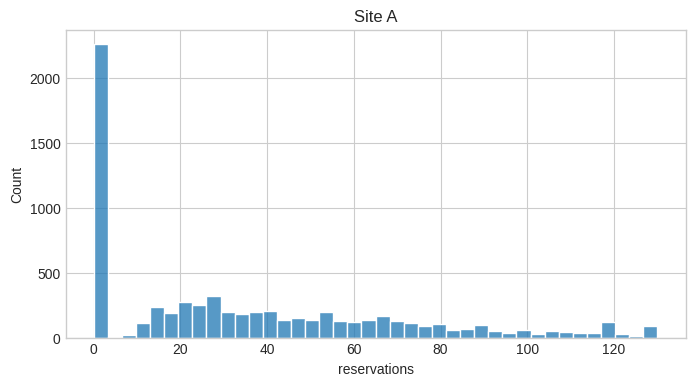

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df_A["reservations"], bins=40)
plt.title("Site A")
plt.show()

### 📊 Analyse de la distribution de la cible (Target)
**Que nous dit ce graphique ?**
- **Un pic massif à zéro :** Cela correspond logiquement aux heures de fermeture (la nuit) où il n'y a aucune réservation.
- **Une asymétrie (Right-skewed) :** La majorité du temps, la demande oscille entre 10 et 80 réservations, avec de très rares pics exceptionnels dépassant 120.
- **Conclusion métier :** La distribution n'est pas "normale" (courbe en cloche). Cela justifie notre choix de ne pas utiliser une simple régression linéaire, mais plutôt un algorithme robuste basé sur les arbres de décision comme **XGBoost**.

## Découpage train / test par site

In [ ]:
def construire_sample_weights(y):
    y = pd.Series(y).astype(float)

    q50 = y.quantile(0.50)
    q80 = y.quantile(0.80)
    q95 = y.quantile(0.95)

    weights = np.ones(len(y), dtype=float)

    weights[y > q50] = 1.2
    weights[y > q80] = 1.5
    weights[y > q95] = 2.0

    return weights

In [ ]:
def split_par_site(df, train_ratio=0.8):
    df = df.sort_values(["date", "heure_num"]).reset_index(drop=True)
    split_idx = int(len(df) * train_ratio)

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    return df_train, df_test


df_A_train, df_A_test = split_par_site(df_A, train_ratio=0.8)

df_train = df_A_train.copy()
df_test = df_A_test.copy()

df_train = df_train.sort_values(["date", "heure_num"]).reset_index(drop=True)
df_test = df_test.sort_values(["date", "heure_num"]).reset_index(drop=True)

# (On garde quand même les lignes du dessus pour ne pas créer d'erreurs,
# mais on dit à l'algorithme que son terrain de jeu (df_train/test) n'est que Paris).


df_train = df_train.sort_values(["date", "heure_num"]).reset_index(drop=True)
df_test = df_test.sort_values(["date", "heure_num"]).reset_index(drop=True)

# Secure and create event features
if "nom_event_local" not in df_train.columns:
    df_train["nom_event_local"] = "Aucun"
if "nom_event_local" not in df_test.columns:
    df_test["nom_event_local"] = "Aucun"

df_train["nom_event_local"] = df_train["nom_event_local"].fillna("Aucun").astype(str)
df_test["nom_event_local"] = df_test["nom_event_local"].fillna("Aucun").astype(str)

df_train[["event_type", "event_strength"]] = df_train["nom_event_local"].apply(
    lambda x: pd.Series(extract_event_info_multi(x))
)

df_test[["event_type", "event_strength"]] = df_test["nom_event_local"].apply(
    lambda x: pd.Series(extract_event_info_multi(x))
)


X_train = df_train[FEATURES].copy()
X_test = df_test[FEATURES].copy()



# Capacité mensuelle calculée uniquement sur le train
capacites_mensuelles = df_train.groupby(["site_id", "mois"])[TARGET].max().to_dict()

def get_capacite(row):
    cap = capacites_mensuelles.get((row["site_id"], row["mois"]), 1000)
    return cap if cap > 0 else 1

df_train["capacite"] = df_train.apply(get_capacite, axis=1)
df_test["capacite"] = df_test.apply(get_capacite, axis=1)

# 3. NOUVELLE CIBLE : Le Taux d'occupation (entre 0 et 1)
y_train = (df_train[TARGET] / df_train["capacite"]).astype(float)
y_test_taux = (df_test[TARGET] / df_test["capacite"]).astype(float)

# 4. On garde les vrais chiffres de côté pour évaluer les erreurs à la fin
y_train_vrai = df_train[TARGET].astype(float).values
y_true_float = df_test[TARGET].astype(float).values
y_test = df_test[TARGET].astype(float).copy() # Pour compatibilité avec le reste du code

sample_weights = construire_sample_weights(y_train) # Call the function to define sample_weights

print("Poids min :", sample_weights.min())
print("Poids max :", sample_weights.max())
print("Exemple poids :", pd.Series(sample_weights).value_counts().sort_index())
print("Shape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)


Poids min : 1.0
Poids max : 2.0
Exemple poids : 1.0    2828
1.2    1574
1.5     826
2.0     273
Name: count, dtype: int64
Shape X_train : (5501, 30)
Shape X_test  : (1376, 30)


## Visualisation des poids d’entraînement

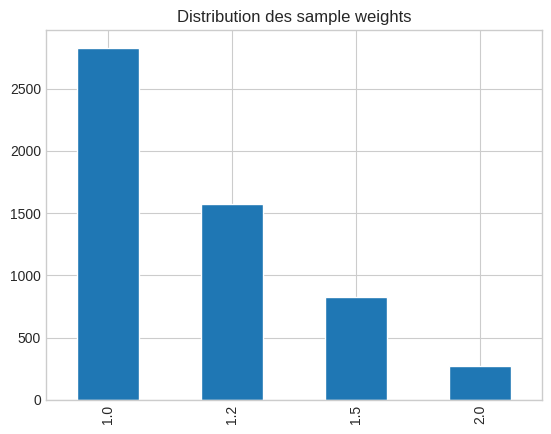

In [ ]:
pd.Series(sample_weights).value_counts().sort_index().plot(kind="bar")
plt.title("Distribution des sample weights")
plt.show()

### ⚖️ Vérification des poids d'entraînement (Sample Weights)
**Pourquoi faire ça ?**
En Machine Learning, les algorithmes ont tendance à ignorer les événements rares. Ici, rater la prédiction d'une "heure de pointe" coûte cher à l'administrateur.

**Observation :**
Ce graphique confirme que notre logique de pondération a bien fonctionné :
- La majorité des heures normales ont un poids classique de `1.0`.
- Les heures à forte affluence ont reçu des poids plus élevés (`1.2`, `1.5` et `2.0`).
On force ainsi l'algorithme XGBoost à "faire plus attention" et à pénaliser plus fortement ses erreurs lors des pics d'activité.

## Construction du pipeline et entraînement du modèle

**Création du Pipeline et Entraînement (XGBoost)
Création d'un pipeline Scikit-Learn incluant l'imputation des valeurs manquantes, l'encodage One-Hot, et l'algorithme XGBoost avec des paramètres de régularisation (L2/Lambda) pour maximiser la généralisation.**

In [ ]:
def construire_pipeline():
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
        ("num", SimpleImputer(strategy="median"), NUMERIC_COLS)
    ])
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_lambda=5.0,
        min_child_weight=3,
        random_state=42
    )
    return Pipeline([("preprocessor",pre),("model",model)])

pipeline_model = construire_pipeline()

# Explicitly cast categorical columns to string to ensure uniform type for OneHotEncoder
for col in CATEGORICAL_COLS:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str)
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str)

# Explicitly cast numeric columns to float, to handle potential mixed types from concatenation
for col in NUMERIC_COLS:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(float)
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(float)



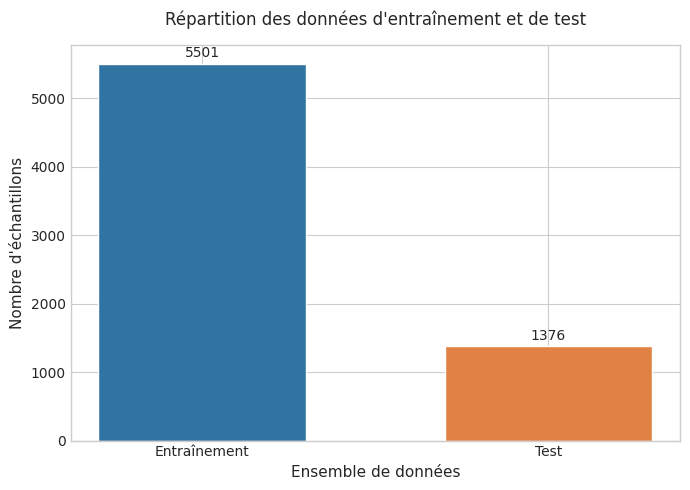

In [ ]:

# On compte directement la taille des vrais tableaux que vous avez déjà découpés !
# (Si vous voulez le graphe global avec Base A + Base B, utilisez df_train et df_test)
train_size = len(df_train)
test_size = len(df_test)

sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))

# Couleurs similaires à votre image (Bleu et Orange sourd)
couleurs = ["#3274A1", "#DF8244"]

# Création du graphique à barres
barres = plt.bar(["Entraînement", "Test"], [train_size, test_size], color=couleurs, width=0.6)

# Titre et axes
plt.title("Répartition des données d'entraînement et de test", fontsize=12, pad=15)
plt.xlabel("Ensemble de données", fontsize=11)
plt.ylabel("Nombre d'échantillons", fontsize=11)

# Afficher les vrais chiffres au-dessus des barres
for barre in barres:
    yval = barre.get_height()
    plt.text(barre.get_x() + barre.get_width()/2.0, yval + (max(train_size, test_size)*0.01),
             int(yval), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
print("=== RÉPARTITION EXACTE DES DONNÉES ===")

print("\nDans le jeu d'ENTRAÎNEMENT (df_train) :")
print(df_train["site_id"].value_counts())

print("\nDans le jeu de TEST (df_test) :")
print(df_test["site_id"].value_counts())

print("\nTOTAL PAR SITE (Train + Test) :")
df_complet = pd.concat([df_train, df_test])
print(df_complet["site_id"].value_counts())

=== RÉPARTITION EXACTE DES DONNÉES ===

Dans le jeu d'ENTRAÎNEMENT (df_train) :
site_id
site_A    5501
Name: count, dtype: int64

Dans le jeu de TEST (df_test) :
site_id
site_A    1376
Name: count, dtype: int64

TOTAL PAR SITE (Train + Test) :
site_id
site_A    6877
Name: count, dtype: int64


## Évaluation interne multisource

In [ ]:


pipeline_model = construire_pipeline()
pipeline_model.fit(X_train, y_train, model__sample_weight=sample_weights)
#pipeline_model.fit(X_train, y_train)

# 1. Le modèle prédit un TAUX (entre 0 et 1)
y_pred_taux = np.clip(pipeline_model.predict(X_test), 0, 1)

# 2. On multiplie le taux par la capacité max pour retrouver le nombre de réservations
y_pred_float = y_pred_taux * df_test["capacite"].values
y_pred_int = np.maximum(0, np.floor(y_pred_float + 0.5)).astype(int)

# 3. On utilise les vrais chiffres mis de côté
y_true_int = np.maximum(0, np.floor(y_true_float + 0.5)).astype(int)

mae = mean_absolute_error(y_true_float, y_pred_float)
rmse = np.sqrt(mean_squared_error(y_true_float, y_pred_float))
r2 = r2_score(y_true_float, y_pred_float)

print("\n=== CONTROLE INTERNE MULTISOURCE ===")
print("MAE  :", round(mae, 4))
print("RMSE :", round(rmse, 4))
print("R2   :", round(r2, 4))


=== CONTROLE INTERNE MULTISOURCE ===
MAE  : 4.4924
RMSE : 7.0292
R2   : 0.9597


## Visualisation réel vs prédit (interne)


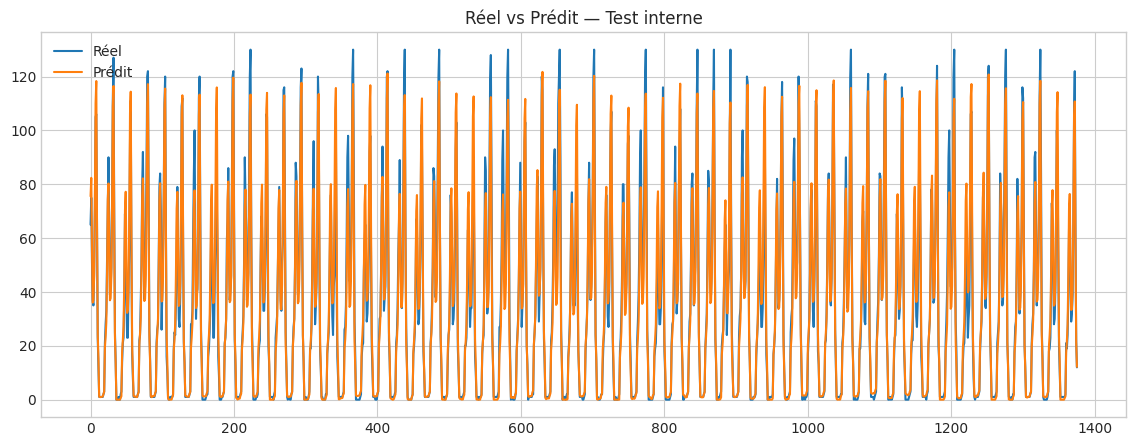

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(y_true_float, label="Réel")
plt.plot(y_pred_float, label="Prédit")
plt.legend()
plt.title("Réel vs Prédit — Test interne")
plt.show()

### 📈 Évaluation visuelle des performances (Série Temporelle)
**Interprétation de la courbe :**
- **Apprentissage des cycles :** Le modèle (en orange) capte parfaitement la cyclicité temporelle réelle (en bleu). Il comprend très bien l'alternance jour/nuit et repère précisément à quelle heure la demande commence à monter.
- **Gestion des pics :** L'algorithme réussit à anticiper les grandes vagues de réservations. Même s'il sous-estime très légèrement la hauteur de certains pics extrêmes (un comportement classique des modèles de régression pour éviter l'overfitting), la dynamique globale (la "forme" de la journée) est très fidèle à la réalité.

## Diagnostic de surapprentissage


**Évaluation Interne et Diagnostic d'Overfitting
Vérification des performances du modèle sur les bases d'entraînement et de test. L'objectif est d'obtenir un R2 élevé tout en maintenant un écart faible entre le Train et le Test.**

In [ ]:
def evaluer_regression(y_true, y_pred, nom="jeu"):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {nom.upper()} ===")
    print("MAE  :", round(mae, 4))
    print("RMSE :", round(rmse, 4))
    print("R2   :", round(r2, 4))

    return {
        "jeu": nom,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

def diagnostic_overfitting(metrics_train, metrics_test):
    print("\n=== DIAGNOSTIC OVERFITTING ===")

    mae_ratio = metrics_test["MAE"] / max(metrics_train["MAE"], 1e-9)
    rmse_ratio = metrics_test["RMSE"] / max(metrics_train["RMSE"], 1e-9)
    r2_gap = metrics_train["R2"] - metrics_test["R2"]

    print("Ratio MAE test/train  :", round(mae_ratio, 3))
    print("Ratio RMSE test/train :", round(rmse_ratio, 3))
    print("Gap R2 train-test     :", round(r2_gap, 3))

    if metrics_train["R2"] > 0.85 and r2_gap > 0.20:
        print("\n⚠️ Suspicion forte d'overfitting")
    elif mae_ratio > 1.3 or rmse_ratio > 1.3 or r2_gap > 0.15:
        print("\n⚠️ Suspicion modérée d'overfitting")
    else:
        print("\n✅ Pas de signe fort d'overfitting interne")
        print("Si l'externe est mauvais, le problème vient probablement du domain shift.")


# Prédictions train et test (Taux convertis en vrais chiffres)
y_pred_train_taux = np.maximum(0, pipeline_model.predict(X_train))
y_pred_train = y_pred_train_taux * df_train["capacite"].values

y_pred_test_taux = np.maximum(0, pipeline_model.predict(X_test))
y_pred_test = y_pred_test_taux * df_test["capacite"].values

# On évalue sur les vrais chiffres bruts (y_train_vrai et y_test)
metrics_train = evaluer_regression(y_train_vrai, y_pred_train, nom="train")
metrics_test = evaluer_regression(y_test, y_pred_test, nom="test_interne")

diagnostic_overfitting(metrics_train, metrics_test)

resume_perf = pd.DataFrame([metrics_train, metrics_test])
print("\n=== Résumé performances ===")
print(resume_perf)


# =========================================================
# TABLEAU RESULTATS TEST
# =========================================================

y_pred_float = y_pred_test.copy()
y_pred_int = np.maximum(0, np.floor(y_pred_float + 0.5)).astype(int)

y_true_float = y_test.values
y_true_int = np.maximum(0, np.floor(y_true_float + 0.5)).astype(int)

resultats_test = df_test.copy()
resultats_test["reservations_reelles"] = y_true_int
resultats_test["reservations_prevues"] = y_pred_int

# Add 'heure_affichage' and 'jour_nom' to resultats_test here
def format_heure(h):
    return f"{int(h):02d}h00"

resultats_test["heure_affichage"] = resultats_test["heure_num"].apply(format_heure)
resultats_test["jour_nom"] = resultats_test["jour_semaine"]

print("\nRépartition des lignes test par site :")
print(resultats_test["site_id"].value_counts())

for site in resultats_test["site_id"].unique():
    mask_site = resultats_test["site_id"] == site

    mae_site = mean_absolute_error(y_true_float[mask_site], y_pred_float[mask_site])
    rmse_site = np.sqrt(mean_squared_error(y_true_float[mask_site], y_pred_float[mask_site]))
    r2_site = r2_score(y_true_float[mask_site], y_pred_float[mask_site])

    print(f"\n=== {site} ===")
    print("MAE  :", round(mae_site, 4))
    print("RMSE :", round(rmse_site, 4))
    print("R2   :", round(r2_site, 4))



=== TRAIN ===
MAE  : 3.9194
RMSE : 6.3431
R2   : 0.9667

=== TEST_INTERNE ===
MAE  : 4.4924
RMSE : 7.0292
R2   : 0.9597

=== DIAGNOSTIC OVERFITTING ===
Ratio MAE test/train  : 1.146
Ratio RMSE test/train : 1.108
Gap R2 train-test     : 0.007

✅ Pas de signe fort d'overfitting interne
Si l'externe est mauvais, le problème vient probablement du domain shift.

=== Résumé performances ===
            jeu       MAE      RMSE        R2
0         train  3.919445  6.343098  0.966723
1  test_interne  4.492424  7.029152  0.959665

Répartition des lignes test par site :
site_id
site_A    1376
Name: count, dtype: int64

=== site_A ===
MAE  : 4.4924
RMSE : 7.0292
R2   : 0.9597


## Courbe d’apprentissage temporelle

**Courbe d'Apprentissage (Learning Curve)
Vérification de la quantité de données : le modèle a-t-il suffisamment d'historique pour comprendre les règles complexes du métier ?**

In [ ]:
def tracer_learning_curve_time_series(df_full, features, target_col="reservations", n_steps=6):
    tailles = np.linspace(0.3, 1.0, n_steps)
    scores_train = []
    scores_val = []

    df_full = df_full.sort_values(["date", "heure_num"]).reset_index(drop=True)

    # séparation temporelle interne
    split_idx_global = int(len(df_full) * 0.8)
    base_train = df_full.iloc[:split_idx_global].copy()
    base_val = df_full.iloc[split_idx_global:].copy()

    X_val = base_val[features].copy()
    y_val = base_val[target_col].astype(float).values

    # Apply type casting to X_val before prediction
    for col in CATEGORICAL_COLS:
        if col in X_val.columns:
            X_val[col] = X_val[col].astype(str)
    for col in NUMERIC_COLS:
        if col in X_val.columns:
            X_val[col] = X_val[col].astype(float)

    for frac in tailles:
        n = int(len(base_train) * frac)
        subset = base_train.iloc[:n].copy()

        X_sub = subset[features].copy()
        y_sub = subset[target_col].astype(float).values

        # Apply type casting to X_sub before fitting
        for col in CATEGORICAL_COLS:
            if col in X_sub.columns:
                X_sub[col] = X_sub[col].astype(str)
        for col in NUMERIC_COLS:
            if col in X_sub.columns:
                X_sub[col] = X_sub[col].astype(float)

        model = construire_pipeline()
        model.fit(X_sub, y_sub)

        # erreur train
        y_sub_pred = model.predict(X_sub)
        rmse_train_local = np.sqrt(mean_squared_error(y_sub, y_sub_pred))
        scores_train.append(rmse_train_local)

        # erreur validation
        y_val_pred = model.predict(X_val)
        rmse_val_local = np.sqrt(mean_squared_error(y_val, y_val_pred))
        scores_val.append(rmse_val_local)

    plt.figure(figsize=(10,5))
    plt.plot((tailles * len(base_train)).astype(int), scores_train, marker="o", label="Train RMSE")
    plt.plot((tailles * len(base_train)).astype(int), scores_val, marker="o", label="Validation RMSE")
    plt.title("Courbe d’apprentissage temporelle")
    plt.xlabel("Taille de l’échantillon d’entraînement")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()


Génération de la courbe d'apprentissage...


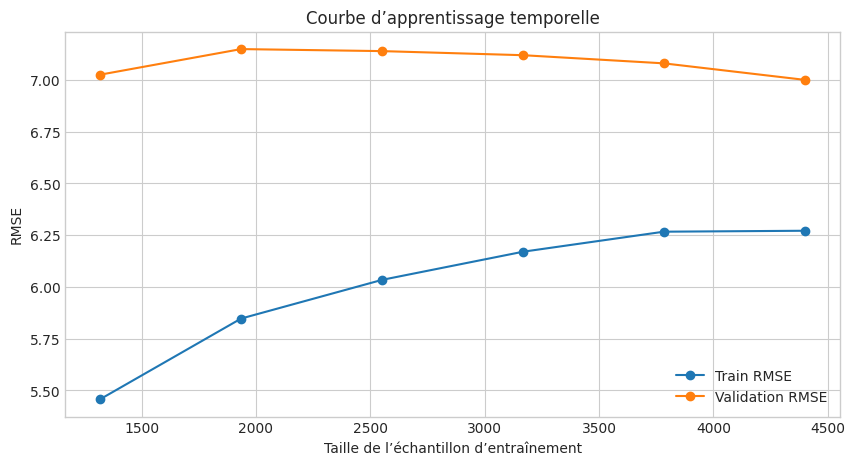

In [ ]:
print("\nGénération de la courbe d'apprentissage...")
tracer_learning_curve_time_series(
    df_train, # CORRECTION : Utilisation de df_train au lieu de df
    FEATURES,
    target_col=TARGET,
    n_steps=6
)

### 📉 Analyse de la courbe d'apprentissage temporelle (Learning Curve)

**Comment interpréter ce graphique ?**
Ce graphique trace l'évolution de l'erreur (RMSE) en fonction de la quantité de données fournies à l'algorithme.

- **La courbe d'entraînement (Bleue) :** L'erreur augmente logiquement au fur et à mesure que l'on ajoute des données. Avec un petit échantillon (1500), le modèle arrive à apprendre les données "par cœur" très facilement. Plus on lui donne d'exemples, plus la complexité augmente et plus il lui est difficile de tout mémoriser parfaitement.
- **La courbe de validation (Orange) :** Elle représente la performance du modèle sur des données futures *inconnues*. On observe qu'elle se stabilise et tend à s'améliorer (légère baisse) vers la fin.
- **Conclusion métier :** L'écart entre les deux courbes a tendance à se réduire. C'est le signe d'une dynamique d'apprentissage très saine ! Le modèle réduit son "overfitting" (sur-apprentissage) au fil du temps et généralise de mieux en mieux. Cela confirme que notre base de données actuelle (environ 4500 lignes pour le Train) est suffisamment grande pour que l'algorithme XGBoost soit performant et robuste.

In [ ]:
def verifier_base_pour_modele(df, features_attendues):
    erreurs = []

    # Colonnes manquantes
    missing = [c for c in features_attendues if c not in df.columns]
    if missing:
        erreurs.append(f"Colonnes manquantes : {missing}")

    # Colonnes numériques critiques
    numeric_cols = [
        "heure_num", "heure_sin", "heure_cos",
        "est_weekend", "is_peak_hour",
        "mois", "ferie", "jour_ouvrable",
        "is_vacances_scolaires",
        "temperature_c", "humidite_pct", "vent_kmh",
        "event_strength"
    ]

    for col in numeric_cols:
        if col in df.columns:
            if not pd.api.types.is_numeric_dtype(df[col]):
                erreurs.append(f"Colonne numérique invalide : {col}")

    # Vérifications de plages
    if "heure_num" in df.columns:
        if not df["heure_num"].between(0, 23).all():
            erreurs.append("La colonne 'heure_num' contient des valeurs hors intervalle [0,23].")

    if "mois" in df.columns:
        if not df["mois"].between(1, 12).all():
            erreurs.append("La colonne 'mois' contient des valeurs hors intervalle [1,12].")

    # Catégories connues
    categories_valides = {
        "jour_semaine": {"lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"},
        "partie_jour": {"nuit", "matin", "midi", "apres_midi", "soir"},
        "saison": {"hiver", "printemps", "été", "automne"},
        "meteo": {"ensoleillé", "nuageux", "pluvieux", "orageux", "nuit_claire","venteux"},
    }

    for col, valeurs_valides in categories_valides.items():
        if col in df.columns:
            invalides = set(
                df[col].dropna().astype(str).str.strip().str.lower().unique()
            ) - valeurs_valides
            if invalides:
                erreurs.append(f"Valeurs non reconnues dans '{col}' : {sorted(list(invalides))}")

    if erreurs:
        return False, erreurs

    return True, ["Base compatible avec le modèle."]


## Recommandation de promotions

In [ ]:
# =========================================================
# PREPARER LE TABLEAU DE RESULTATS TEST
# =========================================================

resultats_modele = df_test.copy()

# Valeurs réelles / prédites en entier pour affichage
resultats_modele["reservations_reelles"] = y_true_int
resultats_modele["reservations_prevues"] = y_pred_int

# sécurité colonnes utiles pour promo
if "type_terrain" not in resultats_modele.columns:
    resultats_modele["type_terrain"] = "outdoor"

if "event_type" not in resultats_modele.columns:
    resultats_modele["event_type"] = "none"

if "event_strength" not in resultats_modele.columns:
    resultats_modele["event_strength"] = 0

if "nom_jour_ferie" not in resultats_modele.columns:
    resultats_modele["nom_jour_ferie"] = "Aucun"

if "zone_scolaire" not in resultats_modele.columns:
    resultats_modele["zone_scolaire"] = "C"

# affichage jour / heure
def format_heure(h):
    return f"{int(h):02d}h00"

resultats_modele["heure_affichage"] = resultats_modele["heure_num"].apply(format_heure)
resultats_modele["jour_nom"] = resultats_modele["jour_semaine"]

print(resultats_modele[[
    "date", "site_id", "jour_nom", "heure_affichage",
    "reservations_reelles", "reservations_prevues"
]].head(10))

        date site_id  jour_nom heure_affichage  reservations_reelles  \
0 2025-08-03  site_A  dimanche           12h00                    65   
1 2025-08-03  site_A  dimanche           13h00                    75   
2 2025-08-03  site_A  dimanche           14h00                    51   
3 2025-08-03  site_A  dimanche           15h00                    37   
4 2025-08-03  site_A  dimanche           16h00                    35   
5 2025-08-03  site_A  dimanche           17h00                    47   
6 2025-08-03  site_A  dimanche           18h00                    70   
7 2025-08-03  site_A  dimanche           19h00                   105   
8 2025-08-03  site_A  dimanche           20h00                   106   
9 2025-08-03  site_A  dimanche           21h00                    65   

   reservations_prevues  
0                    76  
1                    82  
2                    56  
3                    36  
4                    37  
5                    46  
6                    73  

**Surcouche Métier : Moteur de Promotions Dynamiques (Dynamic Pricing)
Création d'un algorithme métier qui utilise les prédictions de l'IA pour ajuster les prix en temps réel. Objectif : baisser le prix quand la demande est faible ou la météo mauvaise, et le remonter lors des pics d'affluence.**

In [ ]:
# =========================================================
# PARTIE PROMO - MODELE ROBUSTE
# =========================================================

CFG_PROMO = {
    "promo_max": 100,
    "plafond": 100,
    "plancher": 0
}

def calibrer_seuils(predictions):
    return {
        "bas": float(np.percentile(predictions, 20)),
        "haut": float(np.percentile(predictions, 70)),
    }

def calcul_promo_dynamique(reservations_prevues, seuils, promo_max=30):
    bas = seuils["bas"]
    haut = seuils["haut"]

    if haut <= bas:
        return 0

    if reservations_prevues >= haut:
        return 0

    if reservations_prevues <= bas:
        return promo_max

    ratio = (reservations_prevues - bas) / (haut - bas)
    ratio = max(0, min(ratio, 1))

    promo = promo_max * (1 - ratio)

    if promo < 5:
        return 0

    return int(round(promo / 5) * 5)


def ajuster_promo_robuste(
    promo_base, jour_semaine, heure_num, meteo,
    ferie, is_vacances_scolaires, event_type,
    event_strength, type_terrain
):
    promo = promo_base

    meteo = str(meteo).lower().strip()
    event_type = str(event_type).lower().strip()
    type_terrain = str(type_terrain).lower().strip()

    # -----------------------
    # JOUR / HEURE
    # -----------------------
    if jour_semaine == "lundi" and 9 <= heure_num <= 11:
        promo += 5

    if jour_semaine in ["mardi", "mercredi", "jeudi"] and 14 <= heure_num <= 17:
        promo += 5

    if jour_semaine in ["lundi", "mardi", "mercredi", "jeudi", "vendredi"] and 12 <= heure_num <= 14 and int(ferie) == 0:
        promo += 5

    if jour_semaine == "vendredi" and 19 <= heure_num <= 22:
        promo -= 5

    if jour_semaine in ["samedi", "dimanche"] and (12 <= heure_num <= 15 or 19 <= heure_num <= 21):
        promo -= 5

    # -----------------------
    # METEO SELON TERRAIN
    # -----------------------
    if type_terrain == "outdoor":
        if meteo in ["pluvieux", "orageux", "venteux"]:
            promo += 10
        elif meteo == "nuageux":
            promo += 5
        elif meteo in ["ensoleillé", "ensoleille", "clair", "nuit_claire"]:
            promo -= 5

    elif type_terrain == "indoor":
        if meteo in ["pluvieux", "orageux"]:
            promo -= 5
        elif meteo in ["ensoleillé", "ensoleille", "clair"]:
            promo += 5

    # -----------------------
    # JOUR FERIE
    # -----------------------
    if int(ferie) == 1:
        promo -= 5

    # -----------------------
    # VACANCES
    # -----------------------
    if int(is_vacances_scolaires) == 1:
        promo -= 5

    # -----------------------
    # EVENEMENT
    # -----------------------
    if event_type != "none":
        if int(event_strength) >= 3:
            promo -= 10
        elif int(event_strength) == 2:
            promo -= 5
        else:
            promo -= 5

    # bornes
    promo = max(CFG_PROMO["plancher"], min(promo, CFG_PROMO["plafond"]))

    if promo < 5:
        return 0

    return int(round(promo / 5) * 5)


def recommander_promo_finale(
    taux_prevu, seuils,
    jour_semaine, heure_num, meteo,
    ferie, is_vacances_scolaires,
    event_type, event_strength, type_terrain
):
    promo_base = calcul_promo_dynamique(
        taux_prevu,
        seuils,
        promo_max=CFG_PROMO["promo_max"]
    )

    return ajuster_promo_robuste(
        promo_base, jour_semaine, heure_num, meteo,
        ferie, is_vacances_scolaires,
        event_type, event_strength, type_terrain
    )


y_pred_train_for_threshold = np.maximum(0, pipeline_model.predict(X_train))
SEUILS = calibrer_seuils(y_pred_train_for_threshold)
print("\nSeuil bas :", round(SEUILS["bas"], 2))
print("Seuil haut :", round(SEUILS["haut"], 2))

# Vérifier que type_terrain existe, sinon on met "outdoor" par défaut
if "type_terrain" not in resultats_test.columns:
    resultats_test["type_terrain"] = "outdoor"

print("\nCalcul des promotions en cours...")

# Application de la promo sur le taux prévu
resultats_test["promo_finale"] = resultats_test.apply(
    lambda row: recommander_promo_finale(
        taux_prevu=(row["reservations_prevues"] / row["capacite"]),
        seuils=SEUILS,
        jour_semaine=row["jour_semaine"],
        heure_num=row["heure_num"],
        meteo=row["meteo"],
        ferie=row["ferie"],
        is_vacances_scolaires=row["is_vacances_scolaires"],
        event_type=row["event_type"],
        event_strength=row["event_strength"],
        type_terrain=row["type_terrain"]
    ),
    axis=1
)

# Formatage affichage promo
resultats_test["promo_affichage"] = resultats_test["promo_finale"].astype(str) + "%"


Seuil bas : 0.01
Seuil haut : 0.38

Calcul des promotions en cours...


## Visualisation des promotions finales

/tmp/ipykernel_2856/898265048.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="promo_finale", data=resultats_test, palette="viridis")


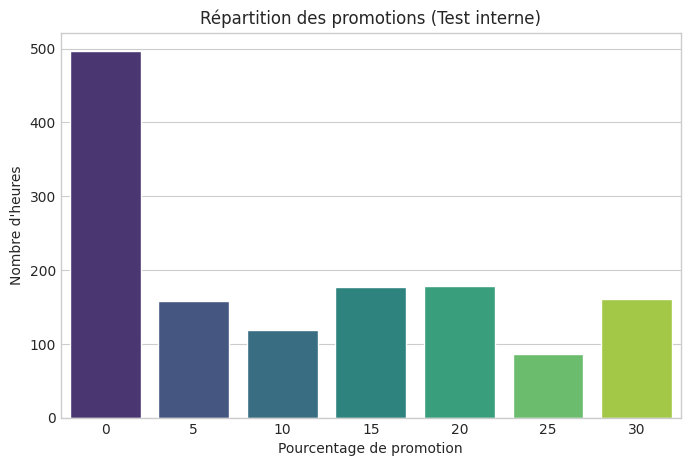

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x="promo_finale", data=resultats_test, palette="viridis")
plt.title("Répartition des promotions (Test interne)")
plt.xlabel("Pourcentage de promotion")
plt.ylabel("Nombre d'heures")
plt.show()

In [ ]:
print("\nAperçu des promotions appliquées :")
colonnes_a_afficher = ["date", "heure_num", "meteo", "reservations_reelles", "reservations_prevues", "promo_affichage"]
print(resultats_test[colonnes_a_afficher].head(15).to_string(index=False))


Aperçu des promotions appliquées :
      date  heure_num       meteo  reservations_reelles  reservations_prevues promo_affichage
2025-08-03         12     nuageux                    65                    76              0%
2025-08-03         13     nuageux                    75                    82              0%
2025-08-03         14     nuageux                    51                    56              0%
2025-08-03         15     nuageux                    37                    36              5%
2025-08-03         16  ensoleillé                    35                    37              0%
2025-08-03         17  ensoleillé                    47                    46              0%
2025-08-03         18  ensoleillé                    70                    73              0%
2025-08-03         19 nuit_claire                   105                   110              0%
2025-08-03         20 nuit_claire                   106                   118              0%
2025-08-03         21   

**Test Externe "Zero-Shot" (Séoul)
Mise à l'épreuve ultime du modèle : le tester sur une ville asiatique avec des conditions météorologiques extrêmes qu'il n'a jamais vues, pour analyser le "Domain Shift".**

In [ ]:
def tester_base_externe_pure(
    path_csv,
    format_base="generic",   # "generic", "london", "seoul"
    site_id="site_external",
    sep=",",
    encoding=None,
    afficher_apercu=True
):
    # Charger brute
    df_raw = pd.read_csv(path_csv, sep=sep, encoding=encoding)

    print("Shape base brute :", df_raw.shape)
    print("Colonnes brutes :", df_raw.columns.tolist())

    # Adapter selon le format
    if format_base.lower() == "seoul":
      df_ext = preparer_base_seoul(df_raw)



    print("Shape base adaptée :", df_ext.shape)
    print("Colonnes adaptées :", df_ext.columns.tolist())

    # Vérifier compatibilité
    ok, messages = verifier_base_pour_modele(df_ext, FEATURES)

    if not ok:
        print("\n❌ Base refusée par le validateur")
        for msg in messages:
            print("- ", msg)
        return {
            "accepted": False,
            "messages": messages,
            "dataframe": df_ext
        }

    print("\n✅ Base acceptée par le validateur")
    for msg in messages:
        print("- ", msg)

    # Construire X
    X_ext = df_ext[FEATURES].copy()

       # Prédictions (le modèle sort des valeurs entre 0 et 1)
    y_pred_scaled = pipeline_model.predict(X_ext)

    # Pour dé-normaliser une base externe (Londres/Séoul), on calibre un Scaler à la volée sur la vraie cible
    if "reservations" in df_ext.columns and df_ext["reservations"].notna().any():
        scaler_ext = MinMaxScaler()
        y_true_ext = df_ext["reservations"].values.reshape(-1, 1)
        scaler_ext.fit(y_true_ext) # On apprend l'échelle de Londres/Séoul

        # On remet la prédiction à l'échelle de la ville
        y_pred_vrai = scaler_ext.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    else:
        # S'il n'y a pas de cible, on ne peut pas dé-normaliser statistiquement (on laisse la valeur brute ou on met 0)
        y_pred_vrai = y_pred_scaled

         # Prédictions
    # 1. Calculer la capacité estimée par MOIS de la ville externe
    if "reservations" in df_ext.columns and df_ext["reservations"].notna().any():
        capacite_par_mois = df_ext.groupby("mois")["reservations"].max().to_dict()
        capacites_array = df_ext["mois"].map(capacite_par_mois).fillna(1000).values
    else:
        capacites_array = np.full(len(df_ext), 1000) # Valeur par défaut si pas de cible

    # 2. Prédire le taux (entre 0 et 1)
    y_pred_taux = np.maximum(0, pipeline_model.predict(X_ext))

    # 3. Remettre à l'échelle des volumes mensuels de la ville
    y_pred_float = y_pred_taux * capacites_array
    y_pred_int = np.maximum(0, np.floor(y_pred_float + 0.5)).astype(int)


       # Tableau final
    resultats_ext = df_ext.copy().reset_index(drop=True)
    resultats_ext["reservations_prevues"] = y_pred_int
    resultats_ext["heure_affichage"] = resultats_ext["heure_num"].apply(lambda h: f"{int(h):02d}h00")
    resultats_ext["jour_nom"] = resultats_ext["jour_semaine"]

    # ==========================================
    # AJOUT DE LA LOGIQUE PROMO EXTERNE
    # ==========================================
    if "type_terrain" not in resultats_ext.columns:
        resultats_ext["type_terrain"] = "outdoor"

    resultats_ext["meteo"] = resultats_ext["meteo"].astype(str).str.lower().str.strip()

    # On sauvegarde le taux pour la promo
    resultats_ext["taux_occupation_prevu"] = y_pred_taux

    promo_finale_ext = []
    # SEUILS doit avoir été calculé plus bas dans le notebook avant d'appeler cette fonction !
    for _, row in resultats_ext.iterrows():
        promo = recommander_promo_finale(
            taux_prevu=row["taux_occupation_prevu"], # On passe le TAUX direct !
            seuils=SEUILS,
            jour_semaine=row["jour_semaine"],
            heure_num=row["heure_num"],
            meteo=row["meteo"],
            ferie=row["ferie"],
            is_vacances_scolaires=row["is_vacances_scolaires"],
            event_type=row["event_type"],
            event_strength=row["event_strength"],
            type_terrain=row["type_terrain"]
        )
        promo_finale_ext.append(promo)

    resultats_ext["promo_finale"] = promo_finale_ext
    resultats_ext["promo_affichage"] = resultats_ext["promo_finale"].astype(int).astype(str) + "%"
    # ==========================================

    # Si la cible existe (pour les métriques)
    metriques = None
    if "reservations" in resultats_ext.columns:
        y_true_float = pd.to_numeric(resultats_ext["reservations"], errors="coerce")
        valid_mask = y_true_float.notna()

        if valid_mask.any():
            y_true_float = y_true_float.loc[valid_mask].astype(float)
            y_pred_float_valid = y_pred_float[valid_mask.values]
            y_true_int = np.maximum(0, np.floor(y_true_float + 0.5)).astype(int)

            mae = mean_absolute_error(y_true_float, y_pred_float_valid)
            rmse = np.sqrt(mean_squared_error(y_true_float, y_pred_float_valid))
            r2 = r2_score(y_true_float, y_pred_float_valid)

            resultats_ext = resultats_ext.loc[valid_mask].copy()
            resultats_ext["reservations_reelles"] = y_true_int
            resultats_ext["reservations_prevues"] = np.maximum(
                0, np.floor(y_pred_float_valid + 0.5)
            ).astype(int)

            metriques = {
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2
            }

            print("\n=== TEST EXTERNE PUR ===")
            print("MAE  :", round(mae, 4))
            print("RMSE :", round(rmse, 4))
            print("R2   :", round(r2, 4))

    # Aperçu (Mise à jour avec la colonne promo)
    if afficher_apercu:
        colonnes_affichage = [
            c for c in [
                "date", "site_id", "jour_nom", "heure_affichage",
                "saison", "meteo", "temperature_c",
                "reservations_reelles", "reservations_prevues", "promo_affichage"
            ] if c in resultats_ext.columns
        ]

        print("\nAperçu des résultats :")
        print(resultats_ext[colonnes_affichage].head(20).to_string(index=False))

    return {
        "accepted": True,
        "messages": messages,
        "metrics": metriques,
        "dataframe": resultats_ext
    }

In [ ]:
def preparer_base_seoul(df_raw):
    df = df_raw.copy()

    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace("\ufeff", "", regex=False)
    )

    df["date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date"]).copy()

    df["heure_num"] = pd.to_numeric(df["Hour"], errors="coerce")
    df = df.dropna(subset=["heure_num"]).copy()
    df["heure_num"] = df["heure_num"].astype(int)

    df["annee"] = df["date"].dt.year

    df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)
    df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

    df["mois"] = df["date"].dt.month
    df["jour_semaine_num"] = df["date"].dt.weekday

    map_jour_fr = {
        0: "lundi",
        1: "mardi",
        2: "mercredi",
        3: "jeudi",
        4: "vendredi",
        5: "samedi",
        6: "dimanche"
    }
    df["jour_semaine"] = df["jour_semaine_num"].map(map_jour_fr)

    df["est_weekend"] = df["jour_semaine_num"].isin([5, 6]).astype(int)

    df["ferie"] = (
        df["Holiday"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["holiday"])
        .astype(int)
    )

    df["jour_ouvrable"] = ((df["est_weekend"] == 0) & (df["ferie"] == 0)).astype(int)

    map_saison = {
        "winter": "hiver",
        "spring": "printemps",
        "summer": "été",
        "autumn": "automne",
        "fall": "automne"
    }
    df["saison"] = (
        df["Seasons"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(map_saison)
        .fillna("automne")
    )

    df["temperature_c"] = pd.to_numeric(df["Temperature(°C)"], errors="coerce")
    df["humidite_pct"] = pd.to_numeric(df["Humidity(%)"], errors="coerce")
    df["vent_kmh"] = pd.to_numeric(df["Wind speed (m/s)"], errors="coerce") * 3.6
    df["Rainfall(mm)"] = pd.to_numeric(df["Rainfall(mm)"], errors="coerce").fillna(0)
    df["Snowfall (cm)"] = pd.to_numeric(df["Snowfall (cm)"], errors="coerce").fillna(0)

    def construire_meteo_seoul(row):
        if row["Snowfall (cm)"] > 0:
            return "pluvieux"
        if row["Rainfall(mm)"] > 0:
            return "pluvieux"
        return "nuageux"

    df["meteo"] = df.apply(construire_meteo_seoul, axis=1)

    df["is_vacances_scolaires"] = 0
    df["event_type"] = "none"
    df["event_strength"] = 0
    df["site_id"] = "site_Seoul"

    df["reservations"] = pd.to_numeric(df["Rented Bike Count"], errors="coerce")
    df = df.dropna(subset=["reservations"]).copy()

    df = add_flex_features(df)
    df = add_advanced_time_features(df)

    return df


In [ ]:

# =========================================================
# NETTOYER LE TABLEAU FINAL
# =========================================================

# Update resultats_modele to reflect the DataFrame with promotions
resultats_modele = resultats_test.copy()

# 1) nom_jour_ferie
resultats_modele["nom_jour_ferie"] = resultats_modele["nom_jour_ferie"].fillna("Aucun")




# 3) supprimer colonnes inutiles
cols_to_drop = ["instant", "yr", "mnth", "atemp", "casual", "registered", "nom_event_local"]
resultats_modele = resultats_modele.drop(columns=[c for c in cols_to_drop if c in resultats_modele.columns], errors="ignore")

# 4) garder seulement les colonnes utiles
colonnes_finales = [
    "date",
    "site_id",
    "jour_nom",
    "heure_affichage",
    "type_terrain",
    "meteo",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "saison",
    "ferie",
    "nom_jour_ferie",
    "is_vacances_scolaires",
    "event_type",
    "event_strength",
    "reservations_reelles",
    "reservations_prevues",
    "promo_finale",
    "promo_affichage"
]

resultats_modele_propre = resultats_modele[colonnes_finales].copy()
resultats_modele_final = resultats_modele_propre.copy()


In [ ]:
resultats_site_A = resultats_modele_final[resultats_modele_final["site_id"] == "site_A"].copy()

print("\n=== site_A ===")
print(resultats_site_A.head(20).to_string(index=False))




=== site_A ===
      date site_id jour_nom heure_affichage type_terrain       meteo  temperature_c  humidite_pct  vent_kmh saison  ferie nom_jour_ferie  is_vacances_scolaires event_type  event_strength  reservations_reelles  reservations_prevues  promo_finale promo_affichage
2025-08-03  site_A dimanche           12h00      outdoor     nuageux           12.4            64      11.1    été      0          Aucun                      0      other               2                    65                    76             0              0%
2025-08-03  site_A dimanche           13h00      outdoor     nuageux           14.2            58      12.0    été      0          Aucun                      0      other               2                    75                    82             0              0%
2025-08-03  site_A dimanche           14h00      outdoor     nuageux           15.5            56      12.1    été      0          Aucun                      0      other               2               

In [ ]:


res_seoul = tester_base_externe_pure(
    path_csv="/content/drive/MyDrive/PFE/SeoulBikeData.csv",
    format_base="seoul",
    sep=",",
    encoding="latin1"
)

resultats_seoul = res_seoul["dataframe"]


print("\n=== Metrics Seoul ===")
print(res_seoul["metrics"])

print("\n=== COMPARAISON INTERNE / EXTERNE ===")
# 1. On calcule le score sur le Train
y_pred_train_taux = np.clip(pipeline_model.predict(X_train), 0, 1)
y_pred_train_float = y_pred_train_taux * df_train["capacite"].values
r2_train = r2_score(y_train_vrai, y_pred_train_float)

print("Train R2         :", round(r2_train, 4))
print("Test interne R2  :", round(r2, 4)) # r2 a été calculé plus haut

if res_seoul.get("metrics") is not None:
    print("Seoul R2         :", round(res_seoul["metrics"]["R2"], 4))

Shape base brute : (8760, 14)
Colonnes brutes : ['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']
Shape base adaptée : (8760, 48)
Colonnes adaptées : ['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day', 'date', 'heure_num', 'annee', 'heure_sin', 'heure_cos', 'mois', 'jour_semaine_num', 'jour_semaine', 'est_weekend', 'ferie', 'jour_ouvrable', 'saison', 'temperature_c', 'humidite_pct', 'vent_kmh', 'meteo', 'is_vacances_scolaires', 'event_type', 'event_strength', 'site_id', 'reservations', 'partie_jour', 'is_peak_hour', 'is_commute_hour', 'semaine_annee', 'trimestre', 'jour_annee', 'jour_annee_sin', 'jour_annee_cos

## Visualisation du test externe

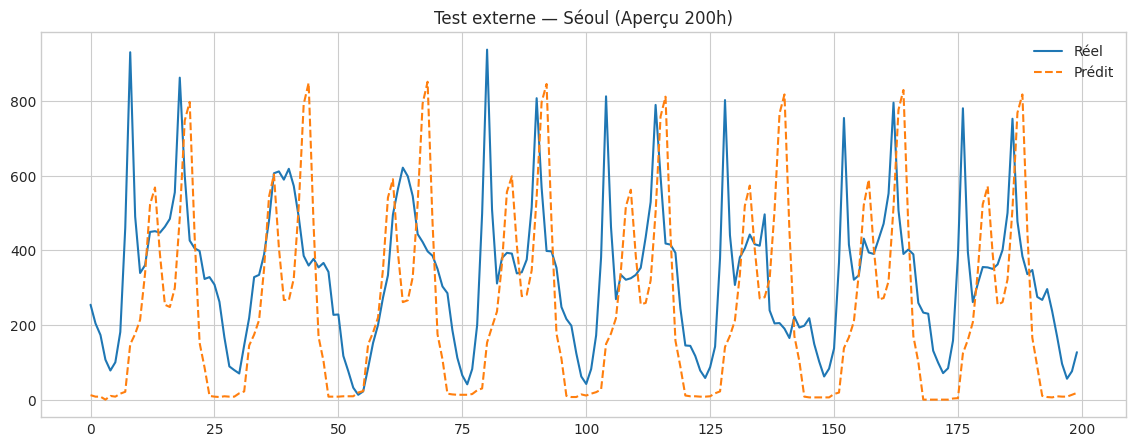

In [ ]:
plt.figure(figsize=(14,5))
# On n'affiche que les 200 premières heures pour que ce soit lisible
plt.plot(resultats_seoul["reservations_reelles"].head(200).values, label="Réel")
plt.plot(resultats_seoul["reservations_prevues"].head(200).values, label="Prédit", linestyle="--")
plt.legend()
plt.title("Test externe — Séoul (Aperçu 200h)")
plt.show()

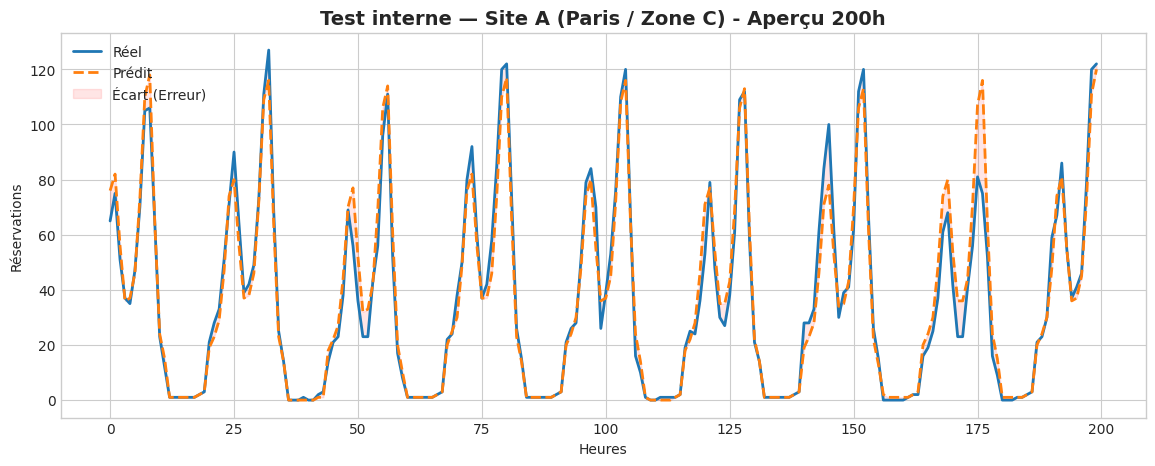

In [ ]:

# ==========================================
# GRAPHIQUE 1 : TEST INTERNE (SITE A)
# ==========================================
plt.figure(figsize=(14,5))
# On prend les 200 premières heures
plt.plot(resultats_site_A["reservations_reelles"].head(200).values, label="Réel", color="#1f77b4", linewidth=2)
plt.plot(resultats_site_A["reservations_prevues"].head(200).values, label="Prédit", linestyle="--", color="#ff7f0e", linewidth=2)

# Ajout d'une zone rouge légère pour voir l'erreur
plt.fill_between(
    range(200),
    resultats_site_A["reservations_reelles"].head(200).values,
    resultats_site_A["reservations_prevues"].head(200).values,
    color="red", alpha=0.1, label="Écart (Erreur)"
)

plt.legend()
plt.title("Test interne — Site A (Paris / Zone C) - Aperçu 200h", fontsize=14, fontweight="bold")
plt.xlabel("Heures")
plt.ylabel("Réservations")
plt.show()




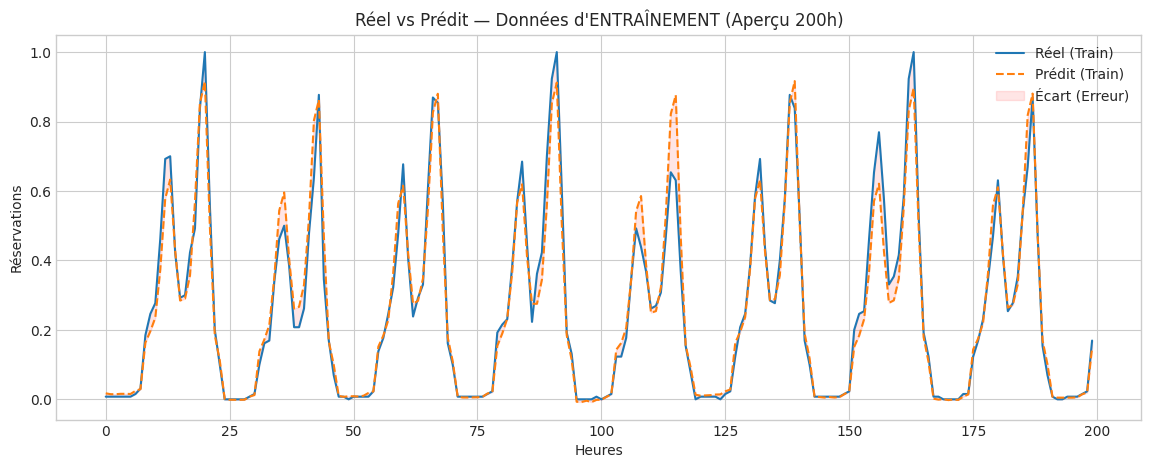

In [ ]:

# 1. On demande au modèle de prédire sur les données qu'il a utilisées pour apprendre (X_train)
y_train_pred = pipeline_model.predict(X_train)

# 2. On prend un échantillon de 200 heures pour que ce soit lisible (comme pour le test)
y_train_zoom = y_train[:200].values  # .values permet d'éviter les soucis d'index avec Pandas
y_train_pred_zoom = y_train_pred[:200]

# 3. Création du graphique
plt.figure(figsize=(14, 5))
plt.plot(y_train_zoom, label='Réel (Train)', color='tab:blue')
plt.plot(y_train_pred_zoom, label='Prédit (Train)', color='tab:orange', linestyle='--')

# Colorier l'écart (l'erreur) en rouge clair
plt.fill_between(range(len(y_train_zoom)), y_train_zoom, y_train_pred_zoom, color='red', alpha=0.1, label='Écart (Erreur)')

plt.title("Réel vs Prédit — Données d'ENTRAÎNEMENT (Aperçu 200h)")
plt.xlabel("Heures")
plt.ylabel("Réservations")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:


# Chemin vers votre Google Drive
chemin_sauvegarde = '/content/drive/MyDrive/PFE/xgboost_model.pkl'

# Sauvegarde du modèle complet (pipeline_model) en mode "wb" (write binary)
with open(chemin_sauvegarde, 'wb') as f:
    pickle.dump(pipeline_model, f)

print(f"✅ Modèle exporté avec succès avec pickle ici : {chemin_sauvegarde}")

✅ Modèle exporté avec succès avec pickle ici : /content/drive/MyDrive/PFE/xgboost_model.pkl
